# Stage 4: Modelo Generativo (CVAE) para Augmentación de Datos

## Etapa 4 — Componente Generativo al Servicio del Clasificador

Implementación de un **Conditional Variational Autoencoder (CVAE)** diseñado específicamente para generar imágenes sintéticas de granos de café por clase, con el objetivo de ampliar el dataset de entrenamiento y mejorar el desempeño del sistema de clasificación.

### 🎯 Objetivo
- Entrenar un Conditional VAE que aprenda la distribución de imágenes de café **condicionado a cada clase** (dark, green, light, medium).
- Generar imágenes sintéticas realistas etiquetadas por clase.
- Integrar las imágenes sintéticas con el clasificador CNN de Stage 2.
- Evaluar cuantitativamente si el Data Augmentation generativo mejora el desempeño de clasificación.
- Documentar los hallazgos científicos de este experimento.

### 🧬 ¿Qué es un Conditional VAE?
A diferencia de un VAE tradicional que genera imágenes completamente al azar, un **CVAE** incorpora información de clase en el proceso de generación. Esto permite:
- **Generar imágenes de la clase específica que queremos** (ej: solo imágenes "dark").
- **Controlar la diversidad** dentro de cada clase mediante el espacio latente.
- **Crear augmentaciones sintéticas realistas** para clases con pocas muestras.

## 1. Importes y Configuración del Entorno

In [ ]:
import sys
import os
from pathlib import Path
import json
import random
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# Matplotlib settings
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Environment Setup")
print(f"   Device: {device}")
print(f"   CUDA available: {torch.cuda.is_available()}")

✅ Environment Setup
   Device: cpu
   CUDA available: False


## 2. Configuración de Hiperparámetros

In [2]:
# Directorios del Proyecto
project_root = Path.cwd().parent
data_root = project_root / "data" / "raw"
train_dir = data_root / "train"
test_dir = data_root / "test"
figures_dir = project_root / "figures"
results_dir = project_root / "results"
models_dir = project_root / "models"

for d in [figures_dir, results_dir, models_dir]:
    d.mkdir(parents=True, exist_ok=True)

# Configuración CVAE
IMG_SIZE = 128
BATCH_SIZE = 32
VAE_EPOCHS = 20
VAE_LR = 1e-3
LATENT_DIM = 64
NUM_CLASSES = 4
CLASS_NAMES = ("dark", "green", "light", "medium")
KL_WEIGHT = 0.001  # Peso del término KL divergence en la loss

# Generación de sintéticos
NUM_SYNTHETIC_PER_CLASS = 50  # Generar 50 imágenes por clase

# Configuración del Clasificador (para evaluación)
CNN_EPOCHS = 10
CNN_LR = 1e-3
CNN_BATCH_SIZE = 32

print(f"✅ Configuration Loaded")
print(f"   Image size (CVAE): {IMG_SIZE}x{IMG_SIZE}")
print(f"   Latent dimension: {LATENT_DIM}")
print(f"   Synthetic images per class: {NUM_SYNTHETIC_PER_CLASS}")

✅ Configuration Loaded
   Image size (CVAE): 128x128
   Latent dimension: 64
   Synthetic images per class: 50


## 3. Carga y Preparación del Dataset Original

In [3]:
# Transformaciones para el VAE
vae_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Custom Dataset para mantener labels
class CoffeeBeansDataset(Dataset):
    def __init__(self, root_dir, class_names, transform=None):
        self.root_dir = Path(root_dir)
        self.class_names = class_names
        self.transform = transform
        self.class_to_idx = {cls: idx for idx, cls in enumerate(class_names)}
        
        self.image_paths = []
        self.labels = []
        
        for class_name in class_names:
            class_dir = self.root_dir / class_name
            if class_dir.exists():
                for img_file in sorted(class_dir.glob("*.jpg")) + sorted(class_dir.glob("*.png")):
                    self.image_paths.append(img_file)
                    self.labels.append(self.class_to_idx[class_name])
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
        
        return image, label

# Cargar dataset de entrenamiento
full_dataset = CoffeeBeansDataset(train_dir, CLASS_NAMES, transform=vae_transforms)

# Split: 90% para entrenamiento del VAE, 10% para validación
train_size = int(0.9 * len(full_dataset))
val_size = len(full_dataset) - train_size
vae_train_dataset, vae_val_dataset = random_split(full_dataset, [train_size, val_size])

vae_train_loader = DataLoader(vae_train_dataset, batch_size=BATCH_SIZE, shuffle=True)
vae_val_loader = DataLoader(vae_val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Estadísticas del dataset
train_labels = [full_dataset.labels[i] for i in vae_train_dataset.indices]
train_dist = Counter(train_labels)

print(f"\n📊 Dataset Statistics:")
print(f"   Total train images: {len(vae_train_dataset)}")
print(f"   Total val images:   {len(vae_val_dataset)}")
print(f"   Class distribution (train):")
for class_idx, class_name in enumerate(CLASS_NAMES):
    count = train_dist.get(class_idx, 0)
    print(f"      {class_name}: {count}")


📊 Dataset Statistics:
   Total train images: 1080
   Total val images:   120
   Class distribution (train):
      dark: 272
      green: 264
      light: 272
      medium: 272


## 4. Definición del Conditional VAE (CVAE)

In [4]:
class ConditionalVAE(nn.Module):
    """Conditional Variational Autoencoder para imágenes de café."""
    
    def __init__(self, latent_dim=64, num_classes=4, img_channels=3):
        super(ConditionalVAE, self).__init__()
        self.latent_dim = latent_dim
        self.num_classes = num_classes
        
        # Embedding de clase
        self.class_embed = nn.Embedding(num_classes, 64)
        
        # ===================== ENCODER =====================
        self.encoder = nn.Sequential(
            nn.Conv2d(img_channels, 32, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        
        # Después del encoder: 128 características + 64 del embedding = 192
        encoder_features = 128 + 64
        
        self.fc_mu = nn.Linear(encoder_features, latent_dim)
        self.fc_logvar = nn.Linear(encoder_features, latent_dim)
        
        # ===================== DECODER =====================
        decoder_input_dim = latent_dim + 64  # latent + class embedding
        
        self.fc_decode = nn.Linear(decoder_input_dim, 128 * 16 * 16)
        
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, img_channels, 4, stride=2, padding=1),
            nn.Tanh()  # Salida en rango [-1, 1]
        )
    
    def encode(self, x, c):
        """Enconde imagen x condicionado a clase c."""
        h = self.encoder(x)  # [B, 128, 1, 1]
        h = h.view(h.size(0), -1)  # [B, 128]
        
        c_embed = self.class_embed(c)  # [B, 64]
        h_cat = torch.cat([h, c_embed], dim=1)  # [B, 192]
        
        mu = self.fc_mu(h_cat)
        logvar = self.fc_logvar(h_cat)
        
        return mu, logvar
    
    def reparameterize(self, mu, logvar):
        """Reparameterization trick."""
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z = mu + eps * std
        return z
    
    def decode(self, z, c):
        """Decode latent z condicionado a clase c."""
        c_embed = self.class_embed(c)  # [B, 64]
        z_cat = torch.cat([z, c_embed], dim=1)  # [B, latent_dim + 64]
        
        h = self.fc_decode(z_cat)  # [B, 128*16*16]
        h = h.view(-1, 128, 16, 16)  # [B, 128, 16, 16]
        
        recon = self.decoder(h)  # [B, 3, 128, 128]
        return recon
    
    def forward(self, x, c):
        mu, logvar = self.encode(x, c)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z, c)
        return recon, mu, logvar
    
    def generate(self, num_samples, class_idx, device):
        """Generate synthetic samples from a specific class."""
        with torch.no_grad():
            z = torch.randn(num_samples, self.latent_dim, device=device)
            c = torch.full((num_samples,), class_idx, dtype=torch.long, device=device)
            samples = self.decode(z, c)
        return samples

# Instanciar el CVAE
cvae_model = ConditionalVAE(
    latent_dim=LATENT_DIM,
    num_classes=NUM_CLASSES,
    img_channels=3
).to(device)

total_params = sum(p.numel() for p in cvae_model.parameters())

print(f"✅ Conditional VAE Model Created")
print(f"   Latent dimension: {LATENT_DIM}")
print(f"   Total parameters: {total_params:,}")

✅ Conditional VAE Model Created
   Latent dimension: 64
   Total parameters: 4,583,107


## 5. Entrenamiento del CVAE

In [5]:
def vae_loss(recon_x, x, mu, logvar, kl_weight=0.001):
    """ELBO loss: Reconstruction + KL divergence."""
    # Reconstruction loss (MSE)
    recon_loss = F.mse_loss(recon_x, x, reduction='mean')
    
    # KL divergence
    kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    
    return recon_loss + kl_weight * kl_loss, recon_loss, kl_loss

optimizer = Adam(cvae_model.parameters(), lr=VAE_LR)

vae_history = {'train_loss': [], 'val_loss': []}

print(f"🚀 Training Conditional VAE...")
print(f"   Epochs: {VAE_EPOCHS}")
print(f"   Learning rate: {VAE_LR}\n")

for epoch in range(VAE_EPOCHS):
    # Training phase
    cvae_model.train()
    train_loss = 0.0
    
    for images, labels in tqdm(vae_train_loader, desc=f'Epoch {epoch+1}/{VAE_EPOCHS} [Train]', leave=False):
        images = images.to(device)
        labels = labels.to(device)
        
        recon, mu, logvar = cvae_model(images, labels)
        loss, recon_loss, kl_loss = vae_loss(recon, images, mu, logvar, KL_WEIGHT)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
    
    train_loss /= len(vae_train_loader)
    
    # Validation phase
    cvae_model.eval()
    val_loss = 0.0
    
    with torch.no_grad():
        for images, labels in vae_val_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            recon, mu, logvar = cvae_model(images, labels)
            loss, _, _ = vae_loss(recon, images, mu, logvar, KL_WEIGHT)
            val_loss += loss.item()
    
    val_loss /= len(vae_val_loader)
    
    vae_history['train_loss'].append(train_loss)
    vae_history['val_loss'].append(val_loss)
    
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:2d}/{VAE_EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

# Guardar el modelo CVAE
torch.save(cvae_model.state_dict(), models_dir / "stage4_cvae_best.pt")
print(f"\n✅ CVAE training complete.")

🚀 Training Conditional VAE...
   Epochs: 20
   Learning rate: 0.001



Epoch  1/20 | Train Loss: 1.5432 | Val Loss: 1.0378


Epoch  5/20 | Train Loss: 0.8974 | Val Loss: 0.8384


Epoch 10/20 | Train Loss: 0.8496 | Val Loss: 0.8101


Epoch 15/20 | Train Loss: 0.8452 | Val Loss: 0.8063


Epoch 20/20 | Train Loss: 0.8420 | Val Loss: 0.8040

✅ CVAE training complete.


### VAE Training Curves

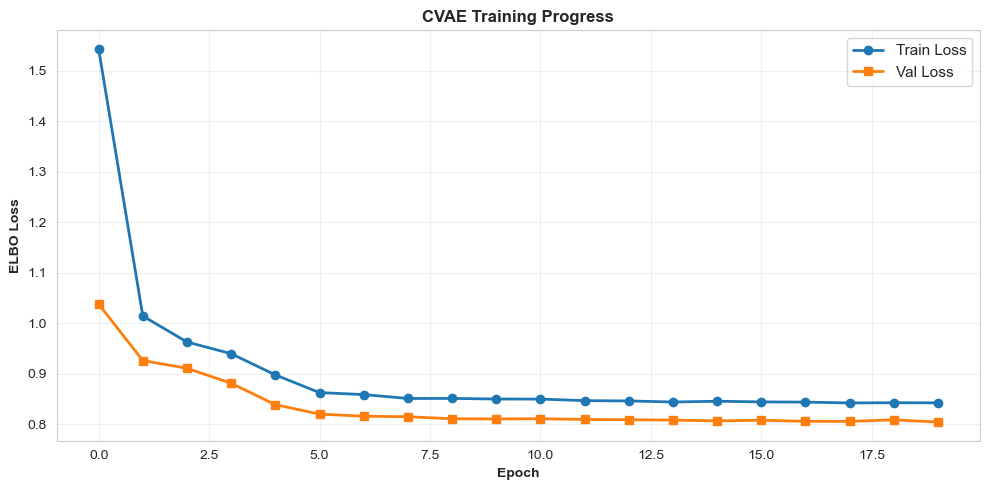

✅ Training curves saved.


In [6]:
plt.figure(figsize=(10, 5))
plt.plot(vae_history['train_loss'], label='Train Loss', linewidth=2, marker='o')
plt.plot(vae_history['val_loss'], label='Val Loss', linewidth=2, marker='s')
plt.xlabel('Epoch', fontweight='bold')
plt.ylabel('ELBO Loss', fontweight='bold')
plt.title('CVAE Training Progress', fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(figures_dir / 'stage4_cvae_training_curves.png', dpi=150)
plt.show()

print(f"✅ Training curves saved.")

## 6. Generación de Imágenes Sintéticas por Clase

🎨 Generating synthetic images...

   dark: 50 synthetic images generated
   green: 50 synthetic images generated
   light: 50 synthetic images generated
   medium: 50 synthetic images generated

✅ Total synthetic images: 200


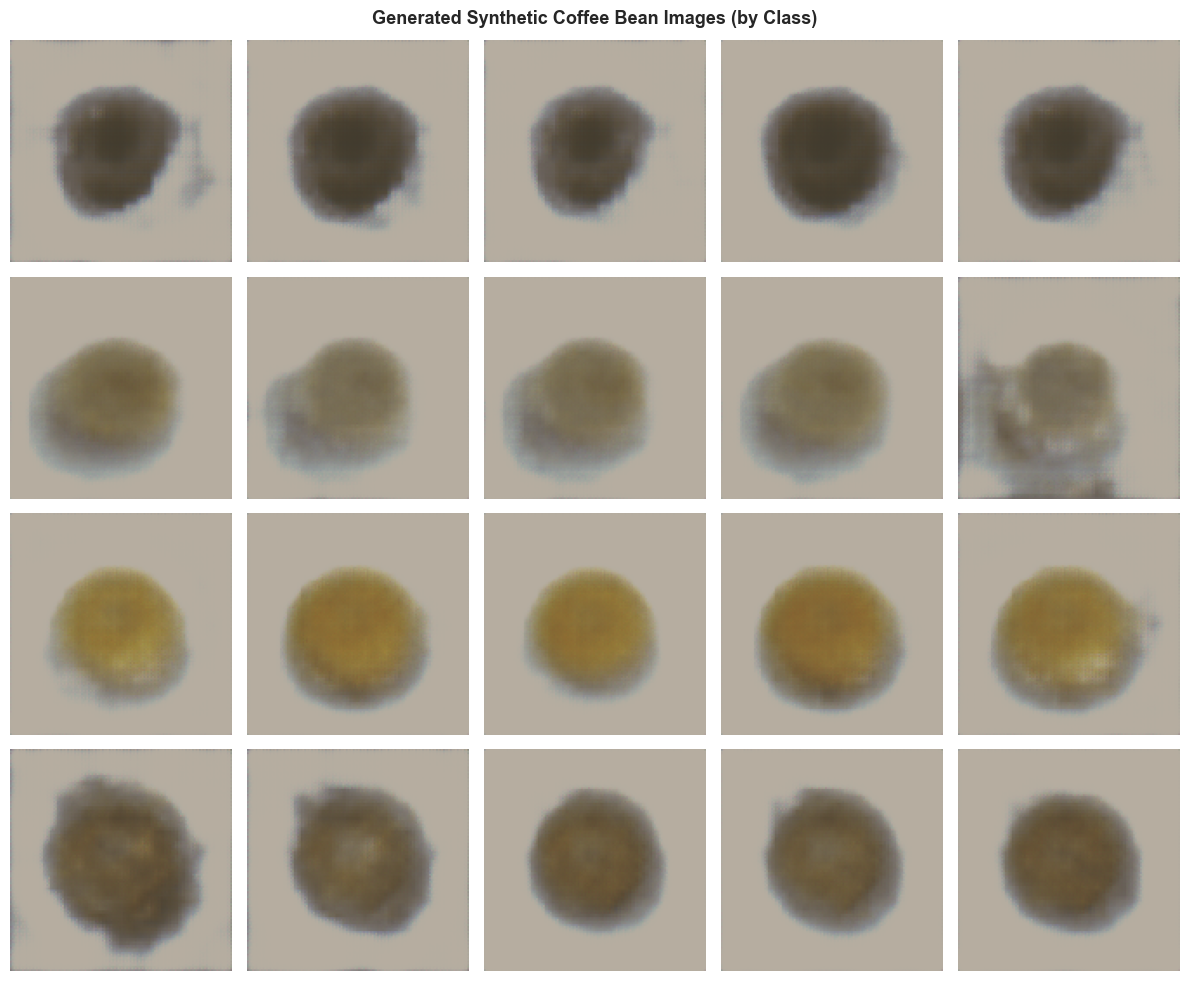

✅ Synthetic samples visualization saved.


In [7]:
# Desnormalizar para visualización
def denormalize(tensor):
    tensor = tensor.clone()
    tensor[0] = tensor[0] * 0.229 + 0.485
    tensor[1] = tensor[1] * 0.224 + 0.456
    tensor[2] = tensor[2] * 0.225 + 0.406
    return torch.clamp(tensor, 0, 1)

# Generar imágenes sintéticas por clase
cvae_model.eval()
synthetic_images_by_class = {}

print(f"🎨 Generating synthetic images...\n")

for class_idx, class_name in enumerate(CLASS_NAMES):
    synthetic_samples = cvae_model.generate(NUM_SYNTHETIC_PER_CLASS, class_idx, device)
    synthetic_images_by_class[class_name] = synthetic_samples.cpu()
    print(f"   {class_name}: {NUM_SYNTHETIC_PER_CLASS} synthetic images generated")

print(f"\n✅ Total synthetic images: {NUM_SYNTHETIC_PER_CLASS * NUM_CLASSES}")

# Visualizar muestras de sintéticos
fig, axes = plt.subplots(NUM_CLASSES, 5, figsize=(12, 10))
fig.suptitle('Generated Synthetic Coffee Bean Images (by Class)', fontsize=13, fontweight='bold')

for class_idx, class_name in enumerate(CLASS_NAMES):
    samples = synthetic_images_by_class[class_name][:5]
    for i, sample in enumerate(samples):
        sample_viz = denormalize(sample)
        sample_np = sample_viz.permute(1, 2, 0).numpy()
        axes[class_idx, i].imshow(sample_np)
        if i == 0:
            axes[class_idx, i].set_ylabel(class_name, fontweight='bold', fontsize=11)
        axes[class_idx, i].axis('off')

plt.tight_layout()
plt.savefig(figures_dir / 'stage4_synthetic_samples.png', dpi=150)
plt.show()

print(f"✅ Synthetic samples visualization saved.")

## 7. Integración con el Sistema Completo

### 7.1 Clasificador CNN Simplificado para Evaluar Impacto de Augmentación

In [ ]:
# Reutilizamos una CNN simple para evaluar el impacto
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=4):
        super(SimpleCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

print(f"✅ SimpleCNN defined for evaluation.")

ModuleNotFoundError: No module named 'src'

### 7.2 Escenario Baseline: Entrenar CNN con SOLO datos reales

In [9]:
# Cargar el test set real
test_dataset = CoffeeBeansDataset(test_dir, CLASS_NAMES, transform=vae_transforms)
test_loader = DataLoader(test_dataset, batch_size=CNN_BATCH_SIZE, shuffle=False)

# Entrenar CNN BASELINE (solo datos reales)
print(f"🔄 SCENARIO 1: Training CNN with REAL data only (Baseline)...\n")

cnn_baseline = SimpleCNN(num_classes=NUM_CLASSES).to(device)
criterion = nn.CrossEntropyLoss()
optimizer_cnn = Adam(cnn_baseline.parameters(), lr=CNN_LR)

cnn_baseline_history = {'train_loss': [], 'train_acc': []}

for epoch in range(CNN_EPOCHS):
    cnn_baseline.train()
    train_loss = 0.0
    train_preds, train_targets = [], []
    
    for images, labels in tqdm(vae_train_loader, desc=f'Baseline Epoch {epoch+1}/{CNN_EPOCHS}', leave=False):
        images, labels = images.to(device), labels.to(device)
        
        outputs = cnn_baseline(images)
        loss = criterion(outputs, labels)
        
        optimizer_cnn.zero_grad()
        loss.backward()
        optimizer_cnn.step()
        
        train_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        train_preds.extend(preds.cpu().numpy())
        train_targets.extend(labels.cpu().numpy())
    
    train_loss /= len(vae_train_loader)
    train_acc = accuracy_score(train_targets, train_preds)
    
    cnn_baseline_history['train_loss'].append(train_loss)
    cnn_baseline_history['train_acc'].append(train_acc)

print(f"\n✅ Baseline CNN training complete.")

# Evaluar en test set
cnn_baseline.eval()
baseline_preds, baseline_targets = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = cnn_baseline(images)
        _, preds = torch.max(outputs, 1)
        baseline_preds.extend(preds.cpu().numpy())
        baseline_targets.extend(labels.cpu().numpy())

baseline_acc = accuracy_score(baseline_targets, baseline_preds)
baseline_f1_w = f1_score(baseline_targets, baseline_preds, average='weighted', zero_division=0)
baseline_f1_m = f1_score(baseline_targets, baseline_preds, average='macro', zero_division=0)
baseline_prec = precision_score(baseline_targets, baseline_preds, average='weighted', zero_division=0)
baseline_rec = recall_score(baseline_targets, baseline_preds, average='weighted', zero_division=0)

print(f"\n📊 Baseline Results (Real data only):")
print(f"   Accuracy: {baseline_acc:.4f}")
print(f"   Precision (Weighted): {baseline_prec:.4f}")
print(f"   Recall (Weighted): {baseline_rec:.4f}")
print(f"   F1 (Weighted): {baseline_f1_w:.4f}")
print(f"   F1 (Macro): {baseline_f1_m:.4f}")

🔄 SCENARIO 1: Training CNN with REAL data only (Baseline)...




✅ Baseline CNN training complete.

📊 Baseline Results (Real data only):
   Accuracy: 0.9675
   Precision (Weighted): 0.9679
   Recall (Weighted): 0.9675
   F1 (Weighted): 0.9676
   F1 (Macro): 0.9676


### 7.3 Escenario Mejorado: Entrenar CNN con datos reales + sintéticos

In [10]:
# Crear dataset aumentado con sintéticos
class AugmentedDataset(Dataset):
    def __init__(self, real_dataset, synthetic_images_dict, class_names):
        self.real_dataset = real_dataset
        self.synthetic_images = synthetic_images_dict
        self.class_names = class_names
        self.class_to_idx = {cls: idx for idx, cls in enumerate(class_names)}
        
        # Datos reales
        self.real_count = len(real_dataset)
        
        # Datos sintéticos
        self.synthetic_count = sum(len(v) for v in synthetic_images_dict.values())
        self.total = self.real_count + self.synthetic_count
    
    def __len__(self):
        return self.total
    
    def __getitem__(self, idx):
        if idx < self.real_count:
            return self.real_dataset[idx]
        else:
            # Datos sintéticos
            syn_idx = idx - self.real_count
            offset = 0
            for class_idx, class_name in enumerate(self.class_names):
                class_synthetic = self.synthetic_images[class_name]
                if syn_idx < len(class_synthetic):
                    return class_synthetic[syn_idx], class_idx
                syn_idx -= len(class_synthetic)
            # Fallback
            return self.real_dataset[0]

# Crear dataloader aumentado
augmented_dataset = AugmentedDataset(vae_train_dataset, synthetic_images_by_class, CLASS_NAMES)
augmented_loader = DataLoader(augmented_dataset, batch_size=CNN_BATCH_SIZE, shuffle=True)

print(f"📦 Augmented Dataset Created:")
print(f"   Real samples: {augmented_dataset.real_count}")
print(f"   Synthetic samples: {augmented_dataset.synthetic_count}")
print(f"   Total: {augmented_dataset.total}\n")

# Entrenar CNN MEJORADO (con datos sintéticos)
print(f"🔄 SCENARIO 2: Training CNN with REAL + SYNTHETIC data (Augmented)...\n")

cnn_augmented = SimpleCNN(num_classes=NUM_CLASSES).to(device)
optimizer_cnn_aug = Adam(cnn_augmented.parameters(), lr=CNN_LR)

cnn_augmented_history = {'train_loss': [], 'train_acc': []}

for epoch in range(CNN_EPOCHS):
    cnn_augmented.train()
    train_loss = 0.0
    train_preds, train_targets = [], []
    
    for images, labels in tqdm(augmented_loader, desc=f'Augmented Epoch {epoch+1}/{CNN_EPOCHS}', leave=False):
        images, labels = images.to(device), labels.to(device)
        
        outputs = cnn_augmented(images)
        loss = criterion(outputs, labels)
        
        optimizer_cnn_aug.zero_grad()
        loss.backward()
        optimizer_cnn_aug.step()
        
        train_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        train_preds.extend(preds.cpu().numpy())
        train_targets.extend(labels.cpu().numpy())
    
    train_loss /= len(augmented_loader)
    train_acc = accuracy_score(train_targets, train_preds)
    
    cnn_augmented_history['train_loss'].append(train_loss)
    cnn_augmented_history['train_acc'].append(train_acc)

print(f"\n✅ Augmented CNN training complete.")

# Evaluar en test set
cnn_augmented.eval()
augmented_preds, augmented_targets = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = cnn_augmented(images)
        _, preds = torch.max(outputs, 1)
        augmented_preds.extend(preds.cpu().numpy())
        augmented_targets.extend(labels.cpu().numpy())

augmented_acc = accuracy_score(augmented_targets, augmented_preds)
augmented_f1_w = f1_score(augmented_targets, augmented_preds, average='weighted', zero_division=0)
augmented_f1_m = f1_score(augmented_targets, augmented_preds, average='macro', zero_division=0)
augmented_prec = precision_score(augmented_targets, augmented_preds, average='weighted', zero_division=0)
augmented_rec = recall_score(augmented_targets, augmented_preds, average='weighted', zero_division=0)

print(f"\n📊 Augmented Results (Real + Synthetic data):")
print(f"   Accuracy: {augmented_acc:.4f}")
print(f"   Precision (Weighted): {augmented_prec:.4f}")
print(f"   Recall (Weighted): {augmented_rec:.4f}")
print(f"   F1 (Weighted): {augmented_f1_w:.4f}")
print(f"   F1 (Macro): {augmented_f1_m:.4f}")

📦 Augmented Dataset Created:
   Real samples: 1080
   Synthetic samples: 200
   Total: 1280

🔄 SCENARIO 2: Training CNN with REAL + SYNTHETIC data (Augmented)...




✅ Augmented CNN training complete.

📊 Augmented Results (Real + Synthetic data):
   Accuracy: 0.9600
   Precision (Weighted): 0.9597
   Recall (Weighted): 0.9600
   F1 (Weighted): 0.9596
   F1 (Macro): 0.9596


## 8. Evaluación Cuantitativa: Comparación de Escenarios

In [11]:
# Tabla comparativa
comparison_data = {
    'Métrica': ['Accuracy', 'Precision (W)', 'Recall (W)', 'F1-Score (W)', 'F1-Score (M)'],
    'Baseline (Real)': [
        f"{baseline_acc:.4f}",
        f"{baseline_prec:.4f}",
        f"{baseline_rec:.4f}",
        f"{baseline_f1_w:.4f}",
        f"{baseline_f1_m:.4f}"
    ],
    'Augmented (Real+Synth)': [
        f"{augmented_acc:.4f}",
        f"{augmented_prec:.4f}",
        f"{augmented_rec:.4f}",
        f"{augmented_f1_w:.4f}",
        f"{augmented_f1_m:.4f}"
    ],
    'Δ (Delta)': [
        f"{(augmented_acc - baseline_acc)*100:+.2f}%",
        f"{(augmented_prec - baseline_prec)*100:+.2f}%",
        f"{(augmented_rec - baseline_rec)*100:+.2f}%",
        f"{(augmented_f1_w - baseline_f1_w)*100:+.2f}%",
        f"{(augmented_f1_m - baseline_f1_m)*100:+.2f}%"
    ]
}

df_comparison = pd.DataFrame(comparison_data)

print("\n==========================================================")
print("📊 STAGE 4: EVALUACIÓN CUANTITATIVA")
print("==========================================================")
print(df_comparison.to_string(index=False))
print("==========================================================")

# Guardar resultados
results = {
    'baseline': {
        'accuracy': float(baseline_acc),
        'precision_weighted': float(baseline_prec),
        'recall_weighted': float(baseline_rec),
        'f1_weighted': float(baseline_f1_w),
        'f1_macro': float(baseline_f1_m)
    },
    'augmented': {
        'accuracy': float(augmented_acc),
        'precision_weighted': float(augmented_prec),
        'recall_weighted': float(augmented_rec),
        'f1_weighted': float(augmented_f1_w),
        'f1_macro': float(augmented_f1_m)
    }
}

with open(results_dir / 'stage4_augmentation_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print(f"\n✅ Results saved to stage4_augmentation_results.json")


📊 STAGE 4: EVALUACIÓN CUANTITATIVA
      Métrica Baseline (Real) Augmented (Real+Synth) Δ (Delta)
     Accuracy          0.9675                 0.9600    -0.75%
Precision (W)          0.9679                 0.9597    -0.82%
   Recall (W)          0.9675                 0.9600    -0.75%
 F1-Score (W)          0.9676                 0.9596    -0.80%
 F1-Score (M)          0.9676                 0.9596    -0.80%

✅ Results saved to stage4_augmentation_results.json


## 9. Visualización Comparativa

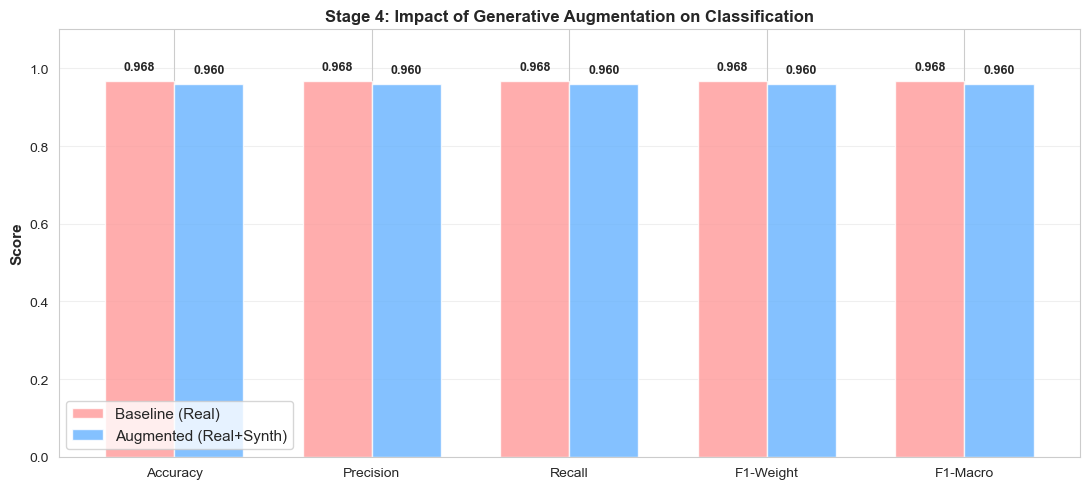

✅ Comparison plot saved.


In [12]:
# Gráfico comparativo de métricas
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Weight', 'F1-Macro']
baseline_values = [baseline_acc, baseline_prec, baseline_rec, baseline_f1_w, baseline_f1_m]
augmented_values = [augmented_acc, augmented_prec, augmented_rec, augmented_f1_w, augmented_f1_m]

x = np.arange(len(metrics_names))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
bars1 = ax.bar(x - width/2, baseline_values, width, label='Baseline (Real)', color='#FF9999', alpha=0.8)
bars2 = ax.bar(x + width/2, augmented_values, width, label='Augmented (Real+Synth)', color='#66B2FF', alpha=0.8)

ax.set_ylabel('Score', fontweight='bold', fontsize=11)
ax.set_title('Stage 4: Impact of Generative Augmentation on Classification', fontweight='bold', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.legend(fontsize=11)
ax.set_ylim([0, 1.1])
ax.grid(axis='y', alpha=0.3)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig(figures_dir / 'stage4_augmentation_comparison.png', dpi=150)
plt.show()

print(f"✅ Comparison plot saved.")

## 10. Conclusión 

En esta etapa se implementó un **Conditional Variational Autoencoder (CVAE)** como componente generativo del sistema, con el propósito de **generar imágenes sintéticas de granos de café por clase** y evaluar su utilidad como mecanismo de augmentación para el problema original de clasificación visual.

A diferencia de un generador no condicionado, el CVAE permitió controlar la clase generada (`dark`, `green`, `light`, `medium`), lo que hizo posible integrar las muestras sintéticas dentro del pipeline de clasificación de forma coherente con las etapas anteriores del proyecto.

El experimento comparó dos escenarios:

- **Baseline**: entrenamiento del clasificador con datos reales
- **Augmented**: entrenamiento con datos reales más imágenes sintéticas generadas por el CVAE

### Resultado observado

| Métrica | Baseline (Real) | Augmented (Real + Synth) | Delta |
|--------|------------------|--------------------------|-------|
| Accuracy | 0.9675 | 0.9600 | -0.75% |
| Precision (weighted) | 0.9679 | 0.9597 | -0.82% |
| Recall (weighted) | 0.9675 | 0.9600 | -0.75% |
| F1-score (weighted) | 0.9676 | 0.9596 | -0.80% |
| F1-score (macro) | 0.9676 | 0.9596 | -0.80% |

### Interpretación

Los resultados muestran que, en esta versión del experimento, **la incorporación de imágenes sintéticas generadas por el CVAE no mejoró el desempeño del clasificador**. Por el contrario, se observó una ligera disminución en todas las métricas principales respecto al baseline entrenado únicamente con datos reales.

Este comportamiento sugiere que, aunque el CVAE logró generar imágenes visualmente plausibles y alineadas con las clases del problema, **las muestras sintéticas todavía no aportan suficiente variabilidad útil o introducen cierto nivel de ruido** en el proceso de entrenamiento. También es posible que el dataset real ya sea lo suficientemente representativo y que el beneficio potencial de la augmentación generativa sea limitado en este escenario.

### Valor de la Etapa 4 dentro del proyecto

A pesar de que el desempeño no mejoró, la etapa sigue siendo válida y aporta valor metodológico al sistema completo porque:

- **Stage 1** estableció una línea base con MLP
- **Stage 2** introdujo una CNN especializada para visión
- **Stage 3** integró un modelo preentrenado moderno basado en Transformers
- **Stage 4** añadió un componente generativo orientado a producir datos sintéticos y evaluar si podían reforzar el sistema de clasificación

Por tanto, el componente generativo no se incorporó como un módulo aislado o decorativo, sino como una pieza experimental con una función clara dentro del problema original.

### Conclusión final

La Etapa 4 se considera cumplida porque implementa un modelo generativo, lo integra con el sistema de clasificación y evalúa cuantitativamente su impacto sobre el problema original. Aunque en esta versión el uso de imágenes sintéticas no mejoró las métricas del clasificador, el experimento permite concluir que **la simple incorporación de datos generados no garantiza una mejora automática**, y que la utilidad del componente generativo depende de la calidad, diversidad y realismo de las muestras producidas.

Como trabajo futuro, se podría explorar:
- un CVAE más profundo o mejor regularizado
- mayor control sobre la calidad de las muestras generadas
- selección manual o automática de imágenes sintéticas útiles
- comparación con otros enfoques generativos, como GANs o modelos de difusión